### NAME: MUHAMMAD DANYAL KHALIL
### REG NO: 22JZELE0473
### UNIVERSITY: UET PESHAWAR (NOWSHERA CAMPUS)
### DEPARTMENT: ELECTRICAL (POWER)
# Lab 8: Designing and Training a Custom CNN

**Course:** Machine Learning Lab  
**Topic:** Convolutional Neural Network for image classification

## Lab Objective
The objective of this lab is to design, train, and evaluate a custom CNN model for classifying images from the dataset prepared in Lab 7.


# Lab Task:

####  Model: Build and train a custom CNN with the following structure:

Conv2D(64 filters, (3Ã—3), ReLU) â†’ BatchNormalization â†’ MaxPooling2D(2Ã—2)

Conv2D(128 filters, (3Ã—3), ReLU) â†’ BatchNormalization â†’ MaxPooling2D(2Ã—2)

Conv2D(256 filters, (3Ã—3), ReLU) â†’ Dropout(0.3) â†’ MaxPooling2D(2Ã—2)

Flatten â†’ Dense(256, ReLU) â†’ Dropout(0.5) â†’ Dense(1, Sigmoid)

#### Dataset: Use only two classes:

from the last lab tasks

#### Compile with: binary_crossentropy loss and adam optimizer.

#### Train and evaluate the model.

## 1. Import Required Libraries
These imports provide Keras layers, model-building tools, optimizers, image data loading utilities, callbacks, plotting functions, and evaluation metrics.


In [1]:
from tensorflow.keras import layers
from tensorflow.keras import models
from tensorflow.keras import optimizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import ModelCheckpoint
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.models import load_model
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import seaborn as sns

## 2. Set Checkpoint Location
The checkpoint path defines where the best model weights will be saved during training based on validation loss.


In [2]:
checkpoints = r'H:\DRIVE D DATA\UET\8th Semester\Machine Learning Lab\lab no 8\checkpoint\ML Lab\lab13\\E1-cp-{epoch:04d}-loss{val_loss:.2f}.h5'

## 3. Define Dataset Directories
The train, validation, and test directories point to the organized image dataset created earlier. These paths are used by `ImageDataGenerator` to load images by class folder.


In [3]:
train_dir = r'H:\DRIVE D DATA\UET\8th Semester\Machine Learning Lab\lab no 7\labno7\train'
validation_dir = r'H:\DRIVE D DATA\UET\8th Semester\Machine Learning Lab\lab no 7\labno7\validation'
test_dir = r'H:\DRIVE D DATA\UET\8th Semester\Machine Learning Lab\lab no 7\labno7\test'

## 4. Build the CNN Architecture
The model uses convolution and pooling layers to extract image features, followed by dense layers for classification. The final softmax layer predicts the image class.


In [4]:
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu',input_shape=(256, 256, 3)))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))
model.add(layers.Flatten())
model.add(layers.Dense(512, activation='relu'))
model.add(layers.Dense(4,activation='softmax'))

c:\Users\Lenovo\anaconda3\envs\DSP\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


## 5. Display Model Summary
The summary shows the output shape and number of trainable parameters for each layer, which helps verify the CNN structure.


In [5]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 254, 254, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 127, 127, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 125, 125, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 62, 62, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 60, 60, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 30, 30, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    12,845,568 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │         2,052 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,088,452 (49.93 MB)

 Trainable params: 13,088,452 (49.93 MB)

 Non-trainable params: 0 (0.00 B)

## 6. Compile the Model
The model is compiled using categorical crossentropy for multi-class classification, RMSprop as the optimizer, and accuracy as the evaluation metric.


In [6]:
model.compile(loss='categorical_crossentropy', optimizer=optimizers.RMSprop(learning_rate=1e-4), metrics=['acc'])

## 7. Load and Rescale Image Data
`ImageDataGenerator` rescales pixel values from 0-255 to 0-1 and loads images from the class folders in batches.


In [7]:
train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)
train_generator = train_datagen.flow_from_directory(train_dir, target_size=(256, 256), batch_size=32,class_mode='categorical')
validation_generator = test_datagen.flow_from_directory(validation_dir,target_size=(256, 256),batch_size=32,class_mode='categorical')

Found 1600 images belonging to 4 classes.
Found 252 images belonging to 4 classes.


## 8. Configure Model Checkpoint
The checkpoint callback saves the best model during training so the model with the lowest validation loss can be reused later.


In [8]:
EpochCheckpoint = ModelCheckpoint(checkpoints,
                             monitor="val_loss",
                             save_best_only=True, 
                             verbose=1)
callbacks = [EpochCheckpoint]

## 9. Train the CNN
The model is trained using batches from the training generator and evaluated on the validation generator after each epoch.


In [9]:
step_size_train = train_generator.n//train_generator.batch_size

model_history = model.fit(train_generator,
                    validation_data =validation_generator,
                   steps_per_epoch=step_size_train,
                   epochs=2,
                    callbacks=callbacks)

Epoch 1/2
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - acc: 0.3803 - loss: 1.3260
Epoch 1: val_loss improved from None to 1.24840, saving model to H:\DRIVE D DATA\UET\8th Semester\Machine Learning Lab\lab no 8\checkpoint\ML Lab\lab13\\E1-cp-0001-loss1.25.h5



Epoch 1: finished saving model to H:\DRIVE D DATA\UET\8th Semester\Machine Learning Lab\lab no 8\checkpoint\ML Lab\lab13\\E1-cp-0001-loss1.25.h5
50/50 ━━━━━━━━━━━━━━━━━━━━ 110s 2s/step - acc: 0.4956 - loss: 1.1430 - val_acc: 0.5079 - val_loss: 1.2484
Epoch 2/2
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - acc: 0.7124 - loss: 0.6844
Epoch 2: val_loss improved from 1.24840 to 0.46318, saving model to H:\DRIVE D DATA\UET\8th Semester\Machine Learning Lab\lab no 8\checkpoint\ML Lab\lab13\\E1-cp-0002-loss0.46.h5



Epoch 2: finished saving model to H:\DRIVE D DATA\UET\8th Semester\Machine Learning Lab\lab no 8\checkpoint\ML Lab\lab13\\E1-cp-0002-loss0.46.h5
50/50 ━━━━━━━━━━━━━━━━━━━━ 89s 2s/step - acc: 0.7337 - loss: 0.6022 - val_acc: 0.7698 - val_loss: 0.4632


## 10. Inspect Training History
The history dictionary stores accuracy and loss values for each epoch. These values are used to understand training progress.


In [10]:
model_history.history

{'acc': [0.49562498927116394, 0.7337499856948853],
 'loss': [1.143000602722168, 0.6021814942359924],
 'val_acc': [0.5079365372657776, 0.7698412537574768],
 'val_loss': [1.248404622077942, 0.46317943930625916]}

## 11. Plot Accuracy and Loss
The plots compare training and validation performance. A large gap between training and validation curves may indicate overfitting.


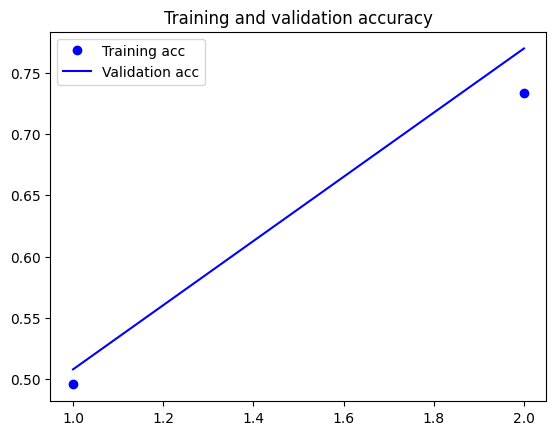

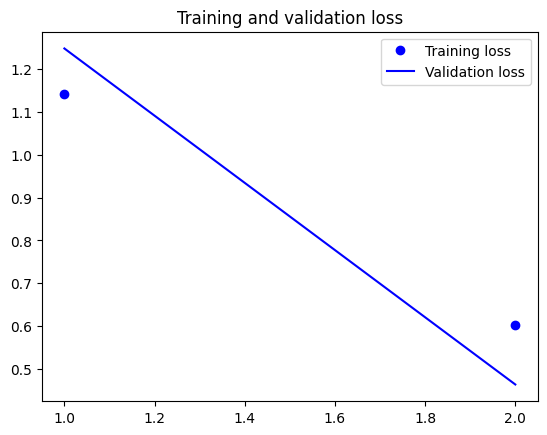

<Figure size 640x480 with 0 Axes>

In [11]:
acc = model_history.history['acc']
val_acc = model_history.history['val_acc']
loss = model_history.history['loss']
val_loss = model_history.history['val_loss']
epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, 'bo', label='Training acc')
plt.plot(epochs, val_acc, 'b', label='Validation acc')
plt.title('Training and validation accuracy')
plt.legend()
plt.figure()
plt.plot(epochs, loss, 'bo', label='Training loss')
plt.plot(epochs, val_loss, 'b', label='Validation loss')
plt.title('Training and validation loss')
plt.legend()
plt.show()
plt.savefig(r'H:\DRIVE D DATA\UET\8th Semester\Machine Learning Lab\lab no 8\model_Accuracy.png')

## 12. Save the Trained Model
Saving the model allows it to be loaded later without retraining.


In [12]:
model.save(r'H:\DRIVE D DATA\UET\8th Semester\Machine Learning Lab\lab no 8\E1-cp-0001-loss0.75.h5')

## 13. Evaluate on Test Data
The test generator loads unseen test images. Predictions are compared with true labels to measure final classification performance.


Found 200 images belonging to 4 classes.
7/7 ━━━━━━━━━━━━━━━━━━━━ 5s 690ms/step


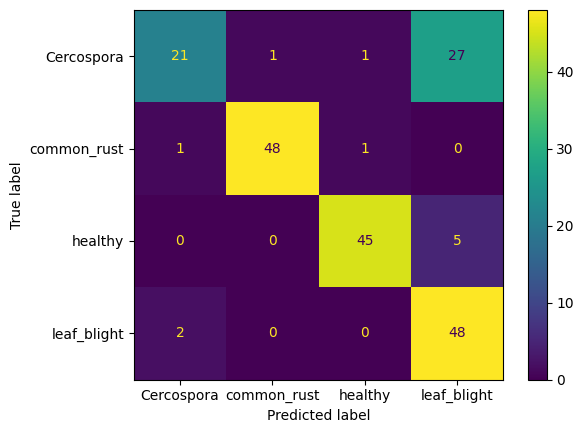

In [13]:
#model = load_model(r'C:\Users\Administrator\Downloads\ML Lab\Computer vision\lab11\model_lab11.h5')
test_datagen = ImageDataGenerator(rescale=1./255)
test_generator = test_datagen.flow_from_directory(test_dir, target_size=(256, 256), batch_size=32, shuffle=False, class_mode='categorical')
label=test_generator.labels
preds=model.predict(test_generator)
pred = np.argmax(preds, axis = 1)
cm = confusion_matrix(label, pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,  display_labels=['Cercospora', 'common_rust','healthy', 'leaf_blight'])
disp.plot()
plt.show()
#plt.savefig(r'C:\Users\Administrator\Downloads\ML Lab\Computer vision\lab11\confusion_matrics.jpg')

## 14. Classification Report
The classification report shows precision, recall, F1-score, and support for each class, giving a clearer evaluation than accuracy alone.


In [14]:
print(classification_report(label, pred, target_names=['Cercospora', 'common_rust','healthy', 'leaf_blight']))

              precision    recall  f1-score   support

  Cercospora       0.88      0.42      0.57        50
 common_rust       0.98      0.96      0.97        50
     healthy       0.96      0.90      0.93        50
 leaf_blight       0.60      0.96      0.74        50

    accuracy                           0.81       200
   macro avg       0.85      0.81      0.80       200
weighted avg       0.85      0.81      0.80       200



## Conclusion
This lab demonstrates the complete CNN workflow: defining the architecture, loading image data, training the model, saving checkpoints, plotting performance, and evaluating the model on test images.
